In [2]:
%pip install opencv-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import cv2
import numpy as np
import pandas as pd
import os
import time
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [8]:
CRACK_DIR = "448/Cracks"
NONCRACK_DIR = "448/NonCracks"

print(os.path.exists(CRACK_DIR))
print(os.path.exists(NONCRACK_DIR))

True
True


In [9]:
def extract_features(image_path):
    
    image = cv2.imread(image_path)
    
    image = cv2.resize(image, (224, 224))
    
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    mean_brightness = np.mean(gray)
    contrast = np.std(gray)
    
    dark_pixel_ratio = np.mean(gray < 50)
    bright_pixel_ratio = np.mean(gray > 200)
    
    min_intensity = np.min(gray)
    max_intensity = np.max(gray)
    median_intensity = np.median(gray)
    
    edges = cv2.Canny(gray, 100, 200)
    
    edge_count = np.sum(edges > 0)
    
    total_pixels = gray.shape[0] * gray.shape[1]
    edge_density = edge_count / total_pixels
    
    return [
        mean_brightness,
        contrast,
        dark_pixel_ratio,
        bright_pixel_ratio,
        min_intensity,
        max_intensity,
        median_intensity,
        edge_count,
        edge_density
    ]

In [7]:
features = []
labels = []
image_names = []

# -----------------------------
# Crack images
# -----------------------------
for filename in os.listdir(CRACK_DIR):

    image_path = os.path.join(CRACK_DIR, filename)

    if filename.lower().endswith((".jpg", ".jpeg", ".png")):

        feature_row = extract_features(image_path)

        features.append(feature_row)
        labels.append(1)
        image_names.append(filename)


# -----------------------------
# Non-crack images
# -----------------------------
for filename in os.listdir(NONCRACK_DIR):

    image_path = os.path.join(NONCRACK_DIR, filename)

    if filename.lower().endswith((".jpg", ".jpeg", ".png")):

        feature_row = extract_features(image_path)

        features.append(feature_row)
        labels.append(0)
        image_names.append(filename)


print("Total images processed:", len(features))

Total images processed: 400


In [10]:
feature_columns = [
    "Mean_Brightness",
    "Contrast",
    "Dark_Pixel_Ratio",
    "Bright_Pixel_Ratio",
    "Min_Intensity",
    "Max_Intensity",
    "Median_Intensity",
    "Edge_Count",
    "Edge_Density"
]

df = pd.DataFrame(features, columns=feature_columns)

df["Image"] = image_names
df["Label"] = labels

# Put Image first
df = df[["Image"] + feature_columns + ["Label"]]

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (400, 11)


,Image,Mean_Brightness,Contrast,Dark_Pixel_Ratio,Bright_Pixel_Ratio,Min_Intensity,Max_Intensity,Median_Intensity,Edge_Count,Edge_Density,Label
0,IMG_20180513_164959951_HDR resized_448.jpg,122.224609,31.513482,0.003846,0.010922,23,247,121.0,17232,0.343431,1
1,IMG_20180513_165129852_HDR resized_448.jpg,131.948681,24.096114,0.002790,0.003787,8,251,133.0,13394,0.266940,1
2,IMG_20180513_165150613_HDR resized_448.jpg,121.297313,29.884272,0.013333,0.008171,2,241,121.0,13185,0.262775,1
3,IMG_20180513_165345878_HDR resized_448.jpg,130.245596,25.649018,0.001893,0.004006,20,253,131.0,16591,0.330656,1
4,IMG_20180513_165349788_HDR resized_448.jpg,131.208885,26.237598,0.002372,0.006258,11,254,132.0,15886,0.316606,1


In [11]:
print("Crack images:", (df["Label"] == 1).sum())
print("Non-crack images:", (df["Label"] == 0).sum())

Crack images: 200
Non-crack images: 200


In [12]:
df.to_csv("image_features.csv", index=False)

print("Feature table saved successfully.")

Feature table saved successfully.


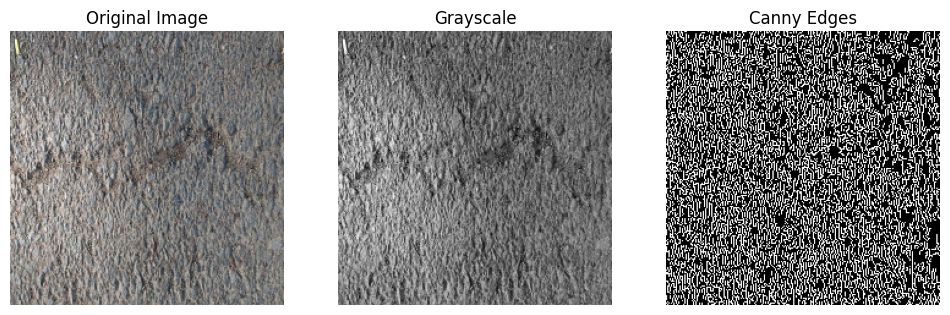

In [13]:
# Take first crack image
sample_image_path = os.path.join(
    CRACK_DIR,
    os.listdir(CRACK_DIR)[0]
)

# Read image
image = cv2.imread(sample_image_path)

# Resize
image = cv2.resize(image, (224, 224))

# Convert for display
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Canny edges
edges = cv2.Canny(gray, 100, 200)

# Plot
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edges")
plt.axis("off")

plt.show()

In [14]:
X = df[feature_columns]

y = df["Label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (400, 9)
y shape: (400,)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(320, 9)
(80, 9)


In [16]:
model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

start_train = time.time()

model_rf.fit(X_train, y_train)

training_time_rf = time.time() - start_train


start_predict = time.time()

y_pred_rf = model_rf.predict(X_test)

prediction_time_rf = time.time() - start_predict

In [17]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1 Score :", f1_rf)

print("Training Time:", training_time_rf)
print("Prediction Time:", prediction_time_rf)

Accuracy : 0.95
Precision: 0.95
Recall   : 0.95
F1 Score : 0.95
Training Time: 0.4823606014251709
Prediction Time: 0.019572734832763672


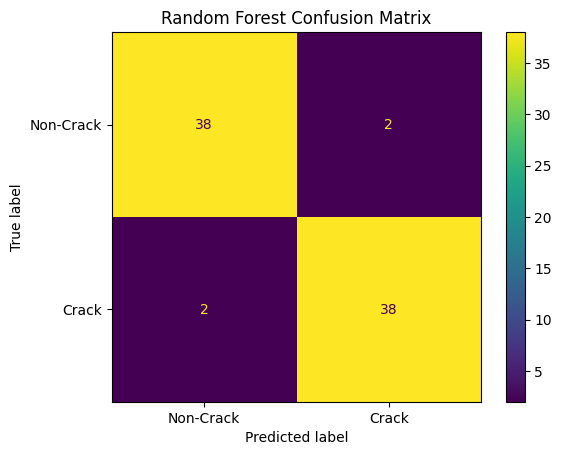

In [18]:
cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Crack", "Crack"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [19]:
model_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(kernel="rbf"))
])

start_train = time.time()

model_svm.fit(X_train, y_train)

training_time_svm = time.time() - start_train


start_predict = time.time()

y_pred_svm = model_svm.predict(X_test)

prediction_time_svm = time.time() - start_predict

In [20]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print("SVM Results")
print("-----------")
print("Accuracy :", accuracy_svm)
print("Precision:", precision_svm)
print("Recall   :", recall_svm)
print("F1 Score :", f1_svm)
print("Training Time:", training_time_svm)
print("Prediction Time:", prediction_time_svm)

SVM Results
-----------
Accuracy : 0.9375
Precision: 0.926829268292683
Recall   : 0.95
F1 Score : 0.9382716049382716
Training Time: 0.06900596618652344
Prediction Time: 0.013225793838500977


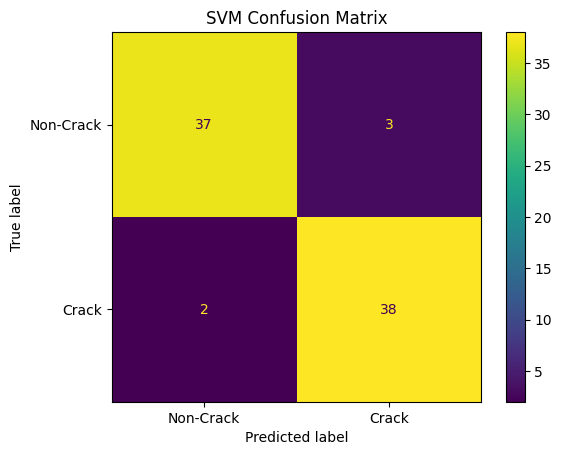

In [21]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["Non-Crack", "Crack"]
)

disp.plot()
plt.title("SVM Confusion Matrix")
plt.show()

In [22]:
results = pd.DataFrame({
    "Model": ["Random Forest", "SVM"],
    "Accuracy": [accuracy_rf, accuracy_svm],
    "Precision": [precision_rf, precision_svm],
    "Recall": [recall_rf, recall_svm],
    "F1-Score": [f1_rf, f1_svm],
    "Training Time (s)": [
        training_time_rf,
        training_time_svm
    ],
    "Prediction Time (s)": [
        prediction_time_rf,
        prediction_time_svm
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
0,Random Forest,0.9500,0.950000,0.95,0.950000,0.482361,0.019573
1,SVM,0.9375,0.926829,0.95,0.938272,0.069006,0.013226


In [24]:
model_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(kernel="rbf"))
])

start_train = time.time()
model_svm.fit(X_train, y_train)
training_time_svm = time.time() - start_train

start_predict = time.time()
y_pred_svm = model_svm.predict(X_test)
prediction_time_svm = time.time() - start_predict

print("SVM training and prediction completed.")

SVM training and prediction completed.


In [25]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print("SVM Results")
print("-----------")
print("Accuracy :", accuracy_svm)
print("Precision:", precision_svm)
print("Recall   :", recall_svm)
print("F1 Score :", f1_svm)
print("Training Time:", training_time_svm)
print("Prediction Time:", prediction_time_svm)

SVM Results
-----------
Accuracy : 0.9375
Precision: 0.926829268292683
Recall   : 0.95
F1 Score : 0.9382716049382716
Training Time: 0.043431997299194336
Prediction Time: 0.010122299194335938


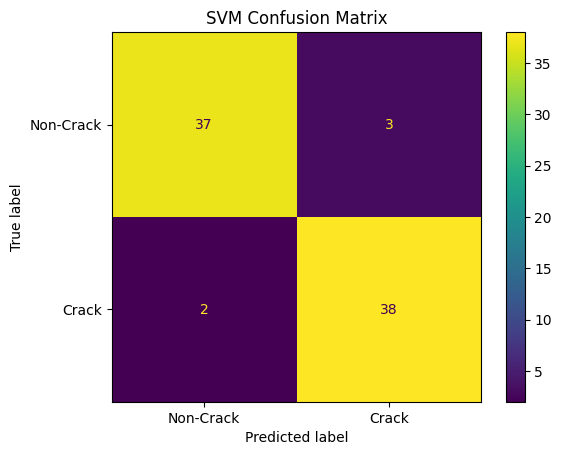

In [26]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["Non-Crack", "Crack"]
)

disp.plot()
plt.title("SVM Confusion Matrix")
plt.show()

In [27]:
results = pd.DataFrame({
    "Model": ["Random Forest", "SVM"],
    "Accuracy": [accuracy_rf, accuracy_svm],
    "Precision": [precision_rf, precision_svm],
    "Recall": [recall_rf, recall_svm],
    "F1-Score": [f1_rf, f1_svm],
    "Training Time (s)": [
        training_time_rf,
        training_time_svm
    ],
    "Prediction Time (s)": [
        prediction_time_rf,
        prediction_time_svm
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
0,Random Forest,0.9500,0.950000,0.95,0.950000,0.482361,0.019573
1,SVM,0.9375,0.926829,0.95,0.938272,0.043432,0.010122


In [28]:
def extract_improved_features(image_path):
    
    image = cv2.imread(image_path)
    image = cv2.resize(image, (224, 224))
    
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Intensity features
    mean_brightness = np.mean(gray)
    contrast = np.std(gray)
    dark_pixel_ratio = np.mean(gray < 50)
    bright_pixel_ratio = np.mean(gray > 200)
    min_intensity = np.min(gray)
    max_intensity = np.max(gray)
    median_intensity = np.median(gray)
    
    # Improved Canny thresholds
    edges = cv2.Canny(gray, 50, 150)
    
    edge_count = np.sum(edges > 0)
    
    total_pixels = gray.shape[0] * gray.shape[1]
    edge_density = edge_count / total_pixels
    
    return [
        mean_brightness,
        contrast,
        dark_pixel_ratio,
        bright_pixel_ratio,
        min_intensity,
        max_intensity,
        median_intensity,
        edge_count,
        edge_density
    ]

In [29]:
improved_features = []

for filename in image_names:
    
    # Check which folder the image belongs to
    if filename in os.listdir(CRACK_DIR):
        image_path = os.path.join(CRACK_DIR, filename)
    else:
        image_path = os.path.join(NONCRACK_DIR, filename)
    
    feature_row = extract_improved_features(image_path)
    improved_features.append(feature_row)

df_improved = pd.DataFrame(
    improved_features,
    columns=feature_columns
)

df_improved["Image"] = image_names
df_improved["Label"] = labels

df_improved = df_improved[
    ["Image"] + feature_columns + ["Label"]
]

print("Improved feature dataset shape:", df_improved.shape)

Improved feature dataset shape: (400, 11)


In [30]:
df_improved.to_csv("image_features_improved.csv", index=False)

print("Improved feature table saved successfully.")

Improved feature table saved successfully.


In [31]:
X_improved = df_improved[feature_columns]

X_train_improved = X_improved.loc[X_train.index]
X_test_improved = X_improved.loc[X_test.index]

y_train_improved = df_improved["Label"].loc[X_train.index]
y_test_improved = df_improved["Label"].loc[X_test.index]

print("Improved training shape:", X_train_improved.shape)
print("Improved testing shape:", X_test_improved.shape)

Improved training shape: (320, 9)
Improved testing shape: (80, 9)


In [32]:
model_svm_improved = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(kernel="rbf"))
])

start_train = time.time()

model_svm_improved.fit(
    X_train_improved,
    y_train_improved
)

training_time_svm_improved = time.time() - start_train

start_predict = time.time()

y_pred_svm_improved = model_svm_improved.predict(
    X_test_improved
)

prediction_time_svm_improved = time.time() - start_predict

print("Improved SVM training and prediction completed.")

Improved SVM training and prediction completed.


In [33]:
accuracy_svm_improved = accuracy_score(
    y_test_improved,
    y_pred_svm_improved
)

precision_svm_improved = precision_score(
    y_test_improved,
    y_pred_svm_improved
)

recall_svm_improved = recall_score(
    y_test_improved,
    y_pred_svm_improved
)

f1_svm_improved = f1_score(
    y_test_improved,
    y_pred_svm_improved
)

print("Improved SVM Results")
print("--------------------")
print("Accuracy :", accuracy_svm_improved)
print("Precision:", precision_svm_improved)
print("Recall   :", recall_svm_improved)
print("F1 Score :", f1_svm_improved)
print("Training Time:", training_time_svm_improved)
print("Prediction Time:", prediction_time_svm_improved)

Improved SVM Results
--------------------
Accuracy : 0.9375
Precision: 0.926829268292683
Recall   : 0.95
F1 Score : 0.9382716049382716
Training Time: 0.2906768321990967
Prediction Time: 0.009076356887817383


In [34]:
accuracy_svm_improved = accuracy_score(
    y_test_improved,
    y_pred_svm_improved
)

precision_svm_improved = precision_score(
    y_test_improved,
    y_pred_svm_improved
)

recall_svm_improved = recall_score(
    y_test_improved,
    y_pred_svm_improved
)

f1_svm_improved = f1_score(
    y_test_improved,
    y_pred_svm_improved
)

print("Improved SVM Results")
print("--------------------")
print("Accuracy :", accuracy_svm_improved)
print("Precision:", precision_svm_improved)
print("Recall   :", recall_svm_improved)
print("F1 Score :", f1_svm_improved)
print("Training Time:", training_time_svm_improved)
print("Prediction Time:", prediction_time_svm_improved)

Improved SVM Results
--------------------
Accuracy : 0.9375
Precision: 0.926829268292683
Recall   : 0.95
F1 Score : 0.9382716049382716
Training Time: 0.2906768321990967
Prediction Time: 0.009076356887817383


In [35]:
comparison = pd.DataFrame({
    "Representation": [
        "Original Canny (100,200)",
        "Improved Canny (50,150)"
    ],
    "Accuracy": [
        accuracy_svm,
        accuracy_svm_improved
    ],
    "Precision": [
        precision_svm,
        precision_svm_improved
    ],
    "Recall": [
        recall_svm,
        recall_svm_improved
    ],
    "F1-Score": [
        f1_svm,
        f1_svm_improved
    ],
    "Training Time (s)": [
        training_time_svm,
        training_time_svm_improved
    ],
    "Prediction Time (s)": [
        prediction_time_svm,
        prediction_time_svm_improved
    ]
})

comparison

,Representation,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
0,"Original Canny (100,200)",0.9375,0.926829,0.95,0.938272,0.043432,0.010122
1,"Improved Canny (50,150)",0.9375,0.926829,0.95,0.938272,0.290677,0.009076
